# 回归与分类评估

学习目标：从预测误差和分类计数推导常用指标，用 NumPy 手写计算并与 scikit-learn 对照，解释单位、正类、平均方式和失效边界。

前置知识：NumPy 一维数组与布尔运算、求和与平均、函数、平方与平方根、回归与分类的区别。

环境准备：[课程环境与运行步骤](README.md)。本章使用 Python、NumPy、Matplotlib 与 scikit-learn；实际验证版本集中在课程说明。root_mean_squared_error 需要 scikit-learn 1.4 及以上，zero_division=np.nan 需要 1.3 及以上。

工作目录：本课程目录。输入均为单元内定义的少量合成数据，无需下载、GPU 或配套脚本；数组表示固定的预测结果，不宣称来自实际业务模型。

运行方式：选择课程内核，重启后从上到下运行全部单元。边界示例会直接显示已说明的指标警告；警告不阻断后续单元。

## 1 先把真实值和预测值对齐

假设要预测四次任务的耗时，单位为分钟。第 $i$ 个样本的真实值为 $y_i$，预测值为 $\hat y_i$；样本数 $n=4$，两个数组形状都为 $(n,)$，相同位置必须对应同一个样本。本章只讨论单目标回归、单标签分类和等权样本。

定义有符号误差 $e_i=\hat y_i-y_i$：正数表示高估，负数表示低估。四个预测分别是 $1,4,8,7$，真实值是 $2,4,6,8$，所以误差为 $-1,0,2,-1$。正负误差的平均值是零，却仍有三个预测不准确；不能把这个平均值当作总体误差大小。

这里使用“预测减真实”的方向，后面的绝对值与平方不受方向影响；画有符号误差图时必须保持这个约定。

In [1]:
import numpy as np

# 两个数组按相同样本顺序排列，浮点数的单位均为分钟。
y = np.array([2, 4, 6, 8], dtype=float)
pred = np.array([1, 4, 8, 7], dtype=float)
e = pred - y

# 预期：误差为 [-1.  0.  2. -1.] 分钟；平均误差为 0.0 分钟。
print("逐样本误差（分钟）：", e)
print("平均误差（分钟）：", e.mean())

逐样本误差（分钟）： [-1.  0.  2. -1.]
平均误差（分钟）： 0.0


## 2 从逐样本误差得到 MAE、MSE 和 RMSE

先消除正负抵消，再对 $n$ 个样本平均，有两种常见选择：绝对值保留误差大小，平方让较大的偏差贡献更多。均方根误差则对均方误差开平方，恢复目标单位。

$$
\operatorname{MAE}=\frac{1}{n}\sum_{i=1}^{n}|e_i|,
\qquad
\operatorname{MSE}=\frac{1}{n}\sum_{i=1}^{n}e_i^2,
\qquad
\operatorname{RMSE}=\sqrt{\operatorname{MSE}}.
$$

| 名称 | 中文名称／含义 | 本例单位 | 优劣方向 |
| --- | --- | --- | --- |
| MAE | 平均绝对误差，平均偏离多少 | 分钟 | 越小越好，最小为 0 |
| MSE | 均方误差，平均平方偏差 | 分钟² | 越小越好，最小为 0 |
| RMSE | 均方根误差，将 MSE 恢复为原单位 | 分钟 | 越小越好，最小为 0 |

代入上节误差：绝对值之和为 $1+0+2+1=4$，平方和为 $1+0+4+1=6$。因此 MAE 为 $4/4=1$ 分钟，MSE 为 $6/4=1.5$ 分钟²，RMSE 为 $\sqrt{1.5}\approx1.2247$ 分钟。RMSE 是“先平均平方，再开方”，不是逐项开方后平均。

In [2]:
def errors(y, pred):
    """输入同长的一维非空数值数组，返回 [MAE, MSE, RMSE]。"""
    # 先按样本求误差，再按定义对绝对值和平方取平均。
    e = pred - y
    mae = np.abs(e).mean()
    mse = (e ** 2).mean()
    return np.array([mae, mse, np.sqrt(mse)])


manual = errors(y, pred)

# 预期：[1.     1.5    1.2247]，单位依次为分钟、分钟²、分钟。
print("手写 MAE、MSE、RMSE：", np.round(manual, 4))

手写 MAE、MSE、RMSE： [1.     1.5    1.2247]


## 3 用框架核对，并观察一个大误差

sklearn.metrics 的误差函数按真实值、预测值的顺序传入。本例不设置 sample_weight，所有样本等权；只处理一维单目标数组，避免把多目标的平均规则混入当前计算。

先核对手写结果，再把第三个预测从 8 改为 12：该点误差从 2 变为 6，绝对误差贡献变为原来的 3 倍，平方误差贡献变为 9 倍。这说明平方损失更重视大偏差；MAE 仍会随大偏差增大，并非不受它影响。

In [3]:
from sklearn import metrics

# 指标顺序与 errors 的返回值保持一致。
lib = np.array([
    metrics.mean_absolute_error(y, pred),
    metrics.mean_squared_error(y, pred),
    metrics.root_mean_squared_error(y, pred),
])

# 预期：框架结果 [1.     1.5    1.2247]；容差内一致为 True。
print("框架 MAE、MSE、RMSE：", np.round(lib, 4))
print("容差内一致：", np.allclose(manual, lib, rtol=1e-12, atol=1e-12))

# 只改变第三个预测，其他真实值与预测保持不变。
pred_big = pred.copy()
pred_big[2] = 12

# 预期：[2.     9.5    3.0822]；平方误差的增幅更突出。
print("改动后 MAE、MSE、RMSE：", np.round(errors(y, pred_big), 4))

框架 MAE、MSE、RMSE： [1.     1.5    1.2247]
容差内一致： True
改动后 MAE、MSE、RMSE： [2.     9.5    3.0822]


## 4 R² 比较的是哪一个基准

决定系数 $R^2$ 把模型的平方误差与“本批真实值的均值”作为固定预测时的平方误差比较。令 $\bar y=\frac1n\sum_i y_i$，模型平方误差和为 $S=\sum_i(y_i-\hat y_i)^2$，均值基准平方误差和为 $T=\sum_i(y_i-\bar y)^2$。当 $T>0$ 时：

$$
R^2=1-\frac{S}{T}.
$$

$S/T$ 是尚未消除的相对平方误差，$1-S/T$ 表示相对该基准减少的比例。因此 $S=0$ 时为 1，$S=T$ 时为 0，$S>T$ 时为负；它不是“准确率”，也不保证落在 $[0,1]$ 内。分子分母单位相同，所以 $R^2$ 无单位。

本例 $\bar y=5$，$T=9+1+1+9=20$，$S=6$，故 $R^2=1-6/20=0.7$。全部预测为 0 时，$S=4+16+36+64=120$，于是 $R^2=-5$。

分母使用评估数据的真实均值是指标定义，不是允许用测试标签训练模型。实际可部署的均值基线只能从训练数据估计，因此它在测试集上的 $R^2$ 不一定恰好为 0。不同数据集的 $T$ 不同，也不能只凭 $R^2$ 跨数据集判断模型优劣。

In [4]:
# 这里的 y 有多个不同取值，因此总离差平方和 t 大于 0。
s = ((y - pred) ** 2).sum()
t = ((y - y.mean()) ** 2).sum()
r2 = 1 - s / t

# 预期：s=6.0、t=20.0；手写与框架 R² 均为 0.7000。
print("模型平方误差和、基准平方误差和：", s, t)
print(f"手写 R²：{r2:.4f}；框架 R²：{metrics.r2_score(y, pred):.4f}")

# 本批均值只用于解释评分基准，不是用测试标签构建可部署的模型。
mean_pred = np.full(y.shape, y.mean())
zero_pred = np.zeros_like(y)

# 预期：本批均值预测得 0.0，全零预测得 -5.0。
print("均值预测 R²：", metrics.r2_score(y, mean_pred))
print("全零预测 R²：", metrics.r2_score(y, zero_pred))

模型平方误差和、基准平方误差和： 6.0 20.0
手写 R²：0.7000；框架 R²：0.7000
均值预测 R²： 0.0
全零预测 R²： -5.0


## 5 常数目标会让 R² 退化

如果所有真实值都相同，$T=0$。预测完全正确时出现 $0/0$，结果为 NaN；预测不完全正确时出现正数除以零，按浮点计算得到 $-\infty$。这批数据没有可供比较的目标变化，有限值替换不能恢复通常的解释。

r2_score 默认 force_finite=True，把上述两种情况分别替换为 1 和 0。设为 False 可观察 NaN 与负无穷；下方保留对应 RuntimeWarning，不把警告隐藏掉。样本数不足 2 时 $R^2$ 也没有定义，应检查评估样本条件，而不是把返回值当作正常分数。

In [5]:
y_flat = np.array([3.0, 3.0, 3.0])
pred_flat = np.array([3.0, 3.0, 4.0])

# 预期：默认替换下，完全正确为 1.0，不完全正确为 0.0。
print("默认值，完全正确：", metrics.r2_score(y_flat, y_flat))
print("默认值，不完全正确：", metrics.r2_score(y_flat, pred_flat))

# 预期：依次为 nan、-inf，并显示无效除法、除以零的 RuntimeWarning。
# 这是为了观察常数目标的退化，不是训练或安装失败。
print("保留退化值，完全正确：", metrics.r2_score(y_flat, y_flat, force_finite=False))
print("保留退化值，不完全正确：", metrics.r2_score(y_flat, pred_flat, force_finite=False))

默认值，完全正确： 1.0
默认值，不完全正确： 0.0
保留退化值，完全正确： nan
保留退化值，不完全正确： -inf


C:\Users\ZHUANG\miniconda3\envs\hands-on-computing\Lib\site-packages\sklearn\metrics\_regression.py:956: RuntimeWarning: invalid value encountered in divide
  output_scores = 1 - (numerator / denominator)
C:\Users\ZHUANG\miniconda3\envs\hands-on-computing\Lib\site-packages\sklearn\metrics\_regression.py:956: RuntimeWarning: divide by zero encountered in divide
  output_scores = 1 - (numerator / denominator)


## 6 把误差画出来

汇总值会丢失误差的位置与方向。左图按样本编号对齐真实耗时和预测耗时，竖线表示二者差距；右图画 $e_i=\hat y_i-y_i$，零线以上为高估、以下为低估。图中 Sample 表示样本编号，Time 和 Error 的单位均为分钟。

这里只展示四个合成样本的具体误差，不据此推断总体分布或模型的泛化能力。

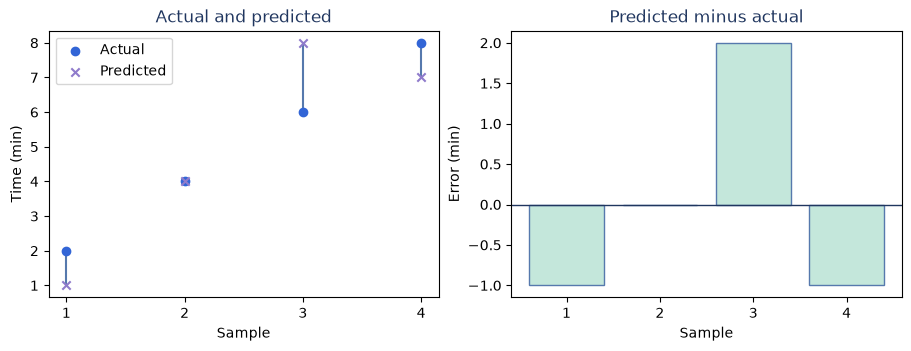

In [6]:
import matplotlib.pyplot as plt

ids = np.arange(1, len(y) + 1)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4), layout="constrained")

# 左图同时用形状和颜色区分真实值与预测值，连接线显示误差大小。
axes[0].vlines(ids, y, pred, color="#5679AD", linewidth=1.5)
axes[0].scatter(ids, y, color="#3265D6", marker="o", label="Actual", zorder=3)
axes[0].scatter(ids, pred, color="#8F7BCB", marker="x", label="Predicted", zorder=3)
axes[0].set(xlabel="Sample", ylabel="Time (min)", xticks=ids)
axes[0].set_title("Actual and predicted", color="#20365F")
axes[0].legend()

# 右图保留误差正负号；横线只代表零误差基准。
axes[1].bar(ids, pred - y, color="#C4E7DB", edgecolor="#5679AD", linewidth=1)
axes[1].axhline(0, color="#20365F", linewidth=1)
axes[1].set(xlabel="Sample", ylabel="Error (min)", xticks=ids)
axes[1].set_title("Predicted minus actual", color="#20365F")

# 预期：第 2 个样本的两个点重合；右图误差依次为 -1、0、2、-1 分钟。
plt.show()

## 7 分类标签、决策分数与概率

分类评估先确认传入的是什么。用来衡量最终判定的指标，与用来衡量排序或概率的指标，需要不同输入。

| 名称 | 中文名称／含义 | 二分类时的含义 |
| --- | --- | --- |
| predict | 最终类别标签 | 每个样本一个类别，例如 0 或 1 |
| decision_function | 决策分数 | 表示判定依据的连续数值，不能直接当作概率 |
| predict_proba | 各类别概率估计 | 每行对应一个样本，列顺序对应模型的 classes_ |

本章的混淆矩阵、accuracy、precision、recall 和 F1 都使用标签。若手里是正类概率 $p_i$，可以先按约定的阈值 $t$ 转成标签；下面人为规定 $p_i\ge t$ 时判为 1。这个示例只说明输入转换，不替代各估计器对阈值相等时的具体规则。

ROC、PR 曲线需要跨阈值比较连续分数，概率损失用于评价概率预测；本章不展开这些指标。阈值选择也应使用训练内部的验证数据，不能看到最终测试结果后不断修改阈值。

In [7]:
# p 是三个样本属于正类 1 的概率估计；不是分类标签数组。
p = np.array([0.2, 0.6, 0.8])
t = 0.5
labels = (p >= t).astype(int)

# 预期：阈值 0.5 下标签为 [0 1 1]；原概率仍为 [0.2 0.6 0.8]。
print("类别标签：", labels)
print("正类概率：", p)

类别标签： [0 1 1]
正类概率： [0.2 0.6 0.8]


## 8 从样本逐个累计混淆矩阵

用 0 表示普通邮件，用 1 表示需要拦截的垃圾邮件，当前关注的正类是 1。“正类”只表示当前关注对象，不表示好坏。混淆矩阵 $C$ 的行是真实类别，列是预测类别；本例固定行列顺序为 $[0,1]$。

| 计数 | 中文名称／含义 | 本例位置 |
| --- | --- | --- |
| TN | 真负例，普通邮件正确保留 | $C_{0,0}$ |
| FP | 假正例，普通邮件被误报为垃圾邮件 | $C_{0,1}$ |
| FN | 假负例，垃圾邮件被漏报为普通邮件 | $C_{1,0}$ |
| TP | 真正例，垃圾邮件正确识别 | $C_{1,1}$ |

下方前六个样本真实类别为 0，预测为四个 0、两个 1，因此第一行为 $[4,2]$；后四个真实类别为 1，预测为一个 0、三个 1，因此第二行为 $[1,3]$。总计十个样本。

In [8]:
y_bin = np.array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1])
pred_bin = np.array([0, 0, 0, 0, 1, 1, 0, 1, 1, 1])

# 仅针对已经编码成 0、1 的本例：类别值可直接作为矩阵下标。
cm = np.zeros((2, 2), dtype=int)
for actual, guess in zip(y_bin, pred_bin):
    cm[actual, guess] += 1

# ravel 按行展平，所以顺序是 TN、FP、FN、TP。
tn, fp, fn, tp = cm.ravel()

# 预期：混淆矩阵为 [[4, 2], [1, 3]]；四项计数依次为 4、2、1、3。
print("手写混淆矩阵：\n", cm)
print("TN、FP、FN、TP：", tn, fp, fn, tp)

手写混淆矩阵：
 [[4 2]
 [1 3]]
TN、FP、FN、TP： 4 2 1 3


## 9 从计数推出 accuracy、precision、recall 和 F1

准确率 accuracy 问“所有样本中判对多少”；精确率 precision 问“判为正类的样本里，有多少真正为正”；召回率 recall 问“真实正类中找回多少”。分母不同，因此不能互换。

$$
A=\frac{TP+TN}{n},\qquad
P=\frac{TP}{TP+FP},\qquad
R=\frac{TP}{TP+FN}.
$$

这里 $A,P,R$ 分别表示准确率、精确率和召回率，均无单位，越大表示对应目标越好。若 $P,R>0$，取它们的调和平均：

$$
F_1=\frac{2}{1/P+1/R}
=\frac{2}{(TP+FP)/TP+(TP+FN)/TP}
=\frac{2TP}{2TP+FP+FN}.
$$

最后的计数形式也适用于 $TP=0$ 且分母大于零的情况，此时 $F_1=0$；分母为零的边界在下节之后单独观察。F1 同时关注精确率和召回率，不计算真负例，也没有替业务指定误报与漏报的实际成本。

本例 $A=7/10=0.7$，$P=3/5=0.6$，$R=3/4=0.75$，$F_1=6/9=2/3$。它们对应四种不同的问题，不能只挑数值最大的指标报告。

In [9]:
# 继续使用上节的四项计数；本例所有分母均大于 0。
acc = (tp + tn) / cm.sum()
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * tp / (2 * tp + fp + fn)
manual_bin = np.array([acc, precision, recall, f1])

# 预期：[0.7 0.6 0.75 0.6667]，依次为 accuracy、precision、recall、F1。
print("手写二分类指标：", np.round(manual_bin, 4))

手写二分类指标： [0.7    0.6    0.75   0.6667]


## 10 框架对照时固定正类与行列顺序

confusion_matrix 的 labels 指定矩阵顺序；二分类的 precision_score、recall_score 和 f1_score 用 pos_label 指定关注哪一类。average="binary" 只报告指定正类，不是对两个类别取平均。

改变 pos_label 只改变评价视角，不会重新训练或修改预测。把 0 视为正类后，精确率是 $4/(4+1)=0.8$，召回率是 $4/(4+2)=2/3$。下方仍把混淆矩阵按 0、1 展示；横轴 Predicted label 表示预测标签，纵轴 True label 表示真实标签。

指标容差内一致： True
矩阵一致： True
类别 0 精确率：0.8000
类别 0 召回率：0.6667


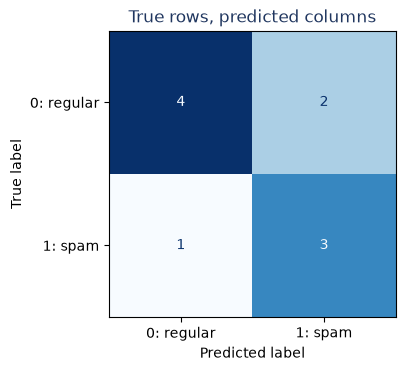

In [10]:
# 对照始终使用相同标签、样本顺序与正类；这里没有样本加权。
lib_bin = np.array([
    metrics.accuracy_score(y_bin, pred_bin),
    metrics.precision_score(y_bin, pred_bin, pos_label=1),
    metrics.recall_score(y_bin, pred_bin, pos_label=1),
    metrics.f1_score(y_bin, pred_bin, pos_label=1),
])
lib_cm = metrics.confusion_matrix(y_bin, pred_bin, labels=[0, 1])

# 预期：四个指标与手写版一致；矩阵逐元素相等，两行均输出 True。
print("指标容差内一致：", np.allclose(manual_bin, lib_bin, rtol=1e-12, atol=1e-12))
print("矩阵一致：", np.array_equal(cm, lib_cm))

# 预期：关注类别 0 时，precision=0.8000，recall=0.6667。
print(f"类别 0 精确率：{metrics.precision_score(y_bin, pred_bin, pos_label=0):.4f}")
print(f"类别 0 召回率：{metrics.recall_score(y_bin, pred_bin, pos_label=0):.4f}")

fig, ax = plt.subplots(figsize=(4.8, 3.6), layout="constrained")
display = metrics.ConfusionMatrixDisplay(lib_cm, display_labels=["0: regular", "1: spam"])
display.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("True rows, predicted columns", color="#20365F")

# 预期：四格依次显示 4、2、1、3；右上为误报 2，左下为漏报 1。
plt.show()

## 11 分母为零时，“0 分”和“没有定义”不同

（1）没有任何预测正类时，$TP+FP=0$，precision 没有定义。若真实正类仍然存在，则 recall 为 0，而 F1 的计数式分母仍大于零，F1 也为 0。

（2）没有任何真实正类时，$TP+FN=0$，recall 没有定义。

（3）真实标签与预测标签中都没有正类时，$TP=FP=FN=0$，F1 也没有定义。

scikit-learn 默认 zero_division="warn" 对未定义结果返回 0，并产生 UndefinedMetricWarning。可以明确设置 zero_division=np.nan 保留缺失含义；之后求平均时该项会被排除，比较模型时必须说明此规则。设置 0 或 1 则是人为约定返回值，不是从零分母推导出的结果。

In [11]:
# 本例真实正类存在，但模型全预测为 0：precision 未定义，recall 和 F1 为 0。
y_miss = np.array([0, 0, 1, 1])
pred_miss = np.zeros(4, dtype=int)

# 预期：显示 UndefinedMetricWarning 并返回 0.0；保留警告以识别未定义值。
print("默认 precision：", metrics.precision_score(y_miss, pred_miss))

# 预期：明确选择缺失约定后 precision 为 nan；F1 的计数分母为 2，所以为 0.0。
print("缺失约定 precision：", metrics.precision_score(y_miss, pred_miss, zero_division=np.nan))
print("此时 F1：", metrics.f1_score(y_miss, pred_miss))

# 当真实值与预测值都没有类别 1，F1 也退化；直接展示默认警告与返回值。
absent = np.array([0, 0, 0, 0])

# 预期：显示 UndefinedMetricWarning，默认 F1 为 0.0；缺失约定下为 nan。
print("正类均不存在时默认 F1：", metrics.f1_score(absent, absent))
print("正类均不存在时缺失 F1：", metrics.f1_score(absent, absent, zero_division=np.nan))

默认 precision： 0.0
缺失约定 precision： nan
此时 F1： 0.0
正类均不存在时默认 F1： 0.0
正类均不存在时缺失 F1： nan


C:\Users\ZHUANG\miniconda3\envs\hands-on-computing\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ZHUANG\miniconda3\envs\hands-on-computing\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## 12 多类别先逐类计算

现在每个样本属于 0、1、2 中的一类。逐类评价时，依次把类别 $k$ 当作正类、其余类别合为负类；$k$ 是类别编号，类别总数为 $K=3$。

对混淆矩阵 $C$，该类真正例为对角元素 $TP_k=C_{k,k}$；列和是预测为该类的数量，行和是真实属于该类的数量。因此：

$$
FP_k=\sum_j C_{j,k}-TP_k,\quad
FN_k=\sum_j C_{k,j}-TP_k,\quad
s_k=\sum_j C_{k,j}.
$$

$s_k$ 是该类的真实样本数，称为支持数 support；$j$ 遍历全部类别。再把每组计数代入二分类公式，即可得到 $P_k,R_k,F_{1,k}$。本例支持数为 $[6,3,1]$，每一类都存在真实样本和预测样本，因此无须增加零分母处理。

In [12]:
y_multi = np.array([0, 0, 0, 0, 0, 0, 1, 1, 1, 2])
pred_multi = np.array([0, 0, 0, 0, 1, 2, 0, 1, 1, 1])

# 1. 固定类别为 0、1、2，按真实行、预测列逐个累计。
cm_multi = np.zeros((3, 3), dtype=int)
for actual, guess in zip(y_multi, pred_multi):
    cm_multi[actual, guess] += 1

# 2. axis=1 对每一行求和；axis=0 对每一列求和。
tp_multi = np.diag(cm_multi)
support = cm_multi.sum(axis=1)
fp_multi = cm_multi.sum(axis=0) - tp_multi
fn_multi = support - tp_multi

# 3. 三个数组的位置分别对应类别 0、1、2，逐类计算，不先合并计数。
p_multi = tp_multi / (tp_multi + fp_multi)
r_multi = tp_multi / (tp_multi + fn_multi)
f_multi = 2 * tp_multi / (2 * tp_multi + fp_multi + fn_multi)

# 预期：矩阵三行为 [4,1,1]、[1,2,0]、[0,1,0]；support 为 [6 3 1]。
print("多类别混淆矩阵：\n", cm_multi)
print("support：", support)

# 预期：P=[0.8,0.5,0]，R≈[0.6667,0.6667,0]，F1≈[0.7273,0.5714,0]。
print("逐类 precision：", np.round(p_multi, 4))
print("逐类 recall：", np.round(r_multi, 4))
print("逐类 F1：", np.round(f_multi, 4))

多类别混淆矩阵：
 [[4 1 1]
 [1 2 0]
 [0 1 0]]
support： [6 3 1]
逐类 precision： [0.8 0.5 0. ]
逐类 recall： [0.6667 0.6667 0.    ]
逐类 F1： [0.7273 0.5714 0.    ]


## 13 macro、weighted 与 micro 的计算顺序

macro 与 weighted 都先逐类计算指标。令 $m_k$ 表示某一类的 precision、recall 或 F1，支持数仍为 $s_k$，总样本数 $n=\sum_k s_k$：

$$
m_{\mathrm{macro}}=\frac{1}{K}\sum_k m_k,
\qquad
m_{\mathrm{weighted}}=\sum_k\frac{s_k}{n}m_k.
$$

macro 让每一类占相同权重；weighted 让真实样本更多的类别占更大权重。特别是 macro F1 要先求各类 F1 再平均，不能把 macro precision 和 macro recall 再代入 F1 公式。

micro 则先把各类 $TP_k,FP_k,FN_k$ 分别求和，再代入 precision、recall 和 F1 的计数公式。在本章“单标签、包含全部类别、等权样本”的条件下，一次错分恰好贡献一个 FP 和另一个类的 FN；一次正确分类贡献一个 TP。因此若 $q$ 为正确数量，就有 $TP_{\mathrm{总}}=q$、$FP_{\mathrm{总}}=FN_{\mathrm{总}}=n-q$，三个 micro 指标都等于 $q/n$，也就是 accuracy。

本例有 6 个正确预测，所以 micro 均为 0.6；macro F1 为 $(8/11+4/7+0)/3\approx0.4329$，weighted F1 为 $0.6(8/11)+0.3(4/7)+0.1(0)\approx0.6078$。少数类 2 完全漏掉，但它在 weighted 中只占十分之一；报告总值时仍应查看逐类结果。

In [13]:
# 每行对应一个类别，每列对应 precision、recall、F1。
per_class = np.column_stack([p_multi, r_multi, f_multi])
macro = per_class.mean(axis=0)
weighted = np.average(per_class, axis=0, weights=support)

# micro 先合并计数，而不是对 per_class 的三行取平均。
tp_sum = tp_multi.sum()
fp_sum = fp_multi.sum()
fn_sum = fn_multi.sum()
micro = np.array([
    tp_sum / (tp_sum + fp_sum),
    tp_sum / (tp_sum + fn_sum),
    2 * tp_sum / (2 * tp_sum + fp_sum + fn_sum),
])

# 预期：macro≈[0.4333,0.4444,0.4329]，weighted≈[0.63,0.6,0.6078]。
print("手写 macro（P、R、F1）：", np.round(macro, 4))
print("手写 weighted（P、R、F1）：", np.round(weighted, 4))

# 预期：micro 为 [0.6 0.6 0.6]，accuracy 为 0.6。
print("手写 micro（P、R、F1）：", micro)
print("accuracy：", (y_multi == pred_multi).mean())

手写 macro（P、R、F1）： [0.4333 0.4444 0.4329]
手写 weighted（P、R、F1）： [0.63   0.6    0.6078]
手写 micro（P、R、F1）： [0.6 0.6 0.6]
accuracy： 0.6


## 14 用同一类别集合核对平均结果

precision_recall_fscore_support 一次返回 precision、recall、F 分数和支持数；默认 beta=1，对应 F1。average=None 返回逐类数组，指定平均方式则返回汇总值，支持数位置为 None。

对照时固定 labels=[0,1,2]。只选择部分类别、加入不存在的类别、改变零分母约定，都会改变评价问题。尤其只选择部分类别时，micro 等于 accuracy 的上述结论不再自动成立。

In [14]:
lib_p, lib_r, lib_f, lib_support = metrics.precision_recall_fscore_support(
    y_multi, pred_multi, labels=[0, 1, 2], average=None
)
lib_per_class = np.column_stack([lib_p, lib_r, lib_f])

# 预期：逐类结果容差内一致为 True；框架 support 为 [6 3 1]。
print("逐类结果一致：", np.allclose(per_class, lib_per_class, rtol=1e-12, atol=1e-12))
print("框架 support：", lib_support)

# 相同调用依次切换平均方式；前三个返回值与手写 P、R、F1 对齐。
for avg, manual_avg in [("macro", macro), ("weighted", weighted), ("micro", micro)]:
    lib_avg = metrics.precision_recall_fscore_support(
        y_multi, pred_multi, labels=[0, 1, 2], average=avg
    )[:3]
    # 预期：三行的“一致”均为 True；数值分别对应上一单元三种手写结果。
    print(avg, np.round(lib_avg, 4), "一致：", np.allclose(manual_avg, lib_avg))

逐类结果一致： True
框架 support： [6 3 1]
macro [0.4333 0.4444 0.4329] 一致： True
weighted [0.63   0.6    0.6078] 一致： True
micro [0.6 0.6 0.6] 一致： True


## 15 先确定要减少哪一种错误

评价前先说明目标、样本集合与单位，再选择主指标。关注平均偏离量可观察 MAE；需要更重视大误差可观察 RMSE，同时保留误差图。分类中，关注预测为正类的结果有多可靠时看 precision，关注真实正类被找回多少时看 recall；F1 可汇总这两者，却不能代替具体成本与混淆计数。

类别不平衡时，仅看 accuracy 容易漏掉少数类失败。下面是人为构造的十个样本：九个普通邮件、一个垃圾邮件；全判为普通邮件就能获得 0.9 的 accuracy，却没有找回任何垃圾邮件。这个算例说明指标的差别，不代表任何真实模型效果。

In [15]:
y_rare = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1])
pred_rare = np.zeros(10, dtype=int)

# 预期：accuracy 为 0.9；正类 recall 和 F1 都是 0.0。
# 此处不计算未定义的 precision；其边界已在前面的示例中单独展示。
print("accuracy：", metrics.accuracy_score(y_rare, pred_rare))
print("正类 recall：", metrics.recall_score(y_rare, pred_rare, pos_label=1))
print("正类 F1：", metrics.f1_score(y_rare, pred_rare, pos_label=1))

accuracy： 0.9
正类 recall： 0.0
正类 F1： 0.0


## 本章小结

（1）MAE、MSE、RMSE 从逐样本误差汇总；说明单位和误差代价，再比较同一批样本上的结果。

（2）$R^2$ 比较模型平方误差与当前真实值均值基准；它可以为负，常数目标和样本不足需要单独解释。

（3）混淆矩阵先固定真实行、预测列与类别顺序；precision、recall 的分母不同，F1 不包含真负例。

（4）多类别先看逐类结果，再选择 macro、weighted 或 micro；相同模型的不同平均方式回答不同问题。

理解自查：能否不调用框架，从四个计数写出 P、R、F1？能否说明为什么某个“0 分”实际上是库对未定义值的约定？

## 练习

### 练习 1：改变耗时的单位

把开头四个样本的真实值与预测值同时乘以 60，将分钟改为秒。先预测 MAE、MSE、RMSE、$R^2$ 分别如何变化，再运行下方代码。

核对标准：用单位换算与公式解释变化倍数；确认 NumPy 与框架仍使用相同输入。不要只记住输出的小数。

In [16]:
# 先写下预测，再运行；这里使用第 2 节已经解释的 errors 函数。
y_sec = y * 60
pred_sec = pred * 60

# 运行后核对：MAE 与 RMSE 是否随单位线性缩放，MSE 如何变化，R² 是否改变。
print("秒制 MAE、MSE、RMSE：", np.round(errors(y_sec, pred_sec), 4))
print("秒制 R²：", metrics.r2_score(y_sec, pred_sec))

秒制 MAE、MSE、RMSE： [  60.     5400.       73.4847]
秒制 R²： 0.7


### 练习 2：降低阈值会改变哪些计数

给定六个样本的真实标签和正类概率，分别按 $p_i\ge0.5$、$p_i\ge0.4$ 分类。先手算两种混淆矩阵，再计算 precision、recall 和 F1，观察是哪一个样本改变了预测。

核对标准：手算矩阵与框架逐项一致；用 TP、FP、FN 的变化解释指标变化。此处概率是固定练习输入，不在最终测试数据上寻找最优阈值，也不能由这六个样本断言降低阈值总能提高 precision 或 F1。

In [17]:
y_ex = np.array([0, 0, 1, 0, 1, 1])
p_ex = np.array([0.15, 0.35, 0.45, 0.65, 0.75, 0.90])

for t in [0.5, 0.4]:
    pred_ex = (p_ex >= t).astype(int)
    cm_ex = metrics.confusion_matrix(y_ex, pred_ex, labels=[0, 1])
    p_val, r_val, f_val, _ = metrics.precision_recall_fscore_support(
        y_ex, pred_ex, average="binary", pos_label=1
    )
    # 运行后核对：哪项预测、哪格计数改变，以及三个指标如何随之变化。
    print("阈值：", t, "预测：", pred_ex)
    print("混淆矩阵：\n", cm_ex)
    print("precision、recall、F1：", np.round([p_val, r_val, f_val], 4))

阈值： 0.5 预测： [0 0 0 1 1 1]
混淆矩阵：
 [[2 1]
 [1 2]]
precision、recall、F1： [0.6667 0.6667 0.6667]
阈值： 0.4 预测： [0 0 1 1 1 1]
混淆矩阵：
 [[2 1]
 [0 3]]
precision、recall、F1： [0.75   1.     0.8571]


### 提示与解析

<details>
<summary>练习 1：先看单位，再看比值</summary>

提示一：换算后每个误差乘以 60；绝对值、平方和平方根分别会如何变化？

提示二：$R^2$ 的分子与分母同时乘以 $60^2$。

解析：MAE 变为 60 秒，MSE 变为 5400 秒²，RMSE 为 $60\sqrt{1.5}\approx73.4847$ 秒，$R^2$ 仍为 0.7。单位变化没有改变预测的相对好坏，却改变了有量纲指标的数值。

</details>

<details>
<summary>练习 2：先定位跨过阈值的样本</summary>

提示一：只有概率为 0.45 的第三个样本跨过阈值，它的真实类别为 1。

提示二：它从 FN 变为 TP；其他三个格子的变化不要凭感觉判断。

解析：阈值 0.5 的矩阵为 $\begin{bmatrix}2&1\\1&2\end{bmatrix}$，P、R、F1 都为 $2/3$。阈值 0.4 的矩阵为 $\begin{bmatrix}2&1\\0&3\end{bmatrix}$，P 为 $3/4$，R 为 1，F1 为 $6/7$。本例没有新增误报；换一组概率与真实标签，降低阈值也可能新增 FP，因此 precision 与 F1 不保证提高。

</details>

## 参考与引用来源

以下为写作时已核查的官方文档；scikit-learn 页面版本为 1.9.1，实际执行环境以课程 README 为准。公式按定义展开，小样本、代数化简与图形为本章教学示例。

（1）scikit-learn：[Metrics and scoring](https://scikit-learn.org/stable/modules/model_evaluation.html)，§3.4.4 分类指标、§3.4.6.1～3 回归指标的公式与单位；[mean_absolute_error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_error.html)、[mean_squared_error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html)、[root_mean_squared_error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.root_mean_squared_error.html) 的输入与返回值；[r2_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html) 的 force_finite、Notes 与常数目标示例；[confusion_matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) 的轴定义与 labels；[accuracy_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html)、[precision_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html)、[recall_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html)、[f1_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html) 的定义、正类与边界；[precision_recall_fscore_support](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_fscore_support.html) 的 average、support、zero_division 与 Notes；[ConfusionMatrixDisplay](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html) 的 plot；[分类决策阈值](https://scikit-learn.org/stable/modules/classification_threshold.html) 的概率、决策分数、标签与验证边界。

（2）NumPy：[mean](https://numpy.org/doc/stable/reference/generated/numpy.mean.html) 的算术平均；[sum](https://numpy.org/doc/stable/reference/generated/numpy.sum.html) 的 axis；[diag](https://numpy.org/doc/stable/reference/generated/numpy.diag.html) 的对角提取；[average](https://numpy.org/doc/stable/reference/generated/numpy.average.html) 的 weights；[allclose](https://numpy.org/doc/stable/reference/generated/numpy.allclose.html) 的浮点容差比较。

（3）Matplotlib：[subplots](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html) 的子图与布局；[Axes.scatter](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.scatter.html)、[Axes.vlines](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.vlines.html)、[Axes.bar](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.bar.html) 的图元与参数；[pyplot.show](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.show.html) 的显式显示。